# 13d — Jump-Diffusion Climate Risk and Piecewise-Exponential Hazard Curves

Covers `chap13_credit9a`, `credit9b`, `credit10`: the Merton (1976)
jump-diffusion firm-value model (sudden transition-risk shocks to asset
value, rather than the continuous drift-adjustment mechanism of `13b`'s
extended Merton model) and a piecewise-constant-hazard survival curve
under baseline vs. two climate-stress scenarios.

**Function-availability note:** `Merton_Jump_Climate_Model.m` and
`survivalExponential.m` are absent from this `hfs-archive` checkout, but
both are already ported and installed as `quanttoolbox.credit.
structural.merton_jump_climate_model` / `quanttoolbox.credit.
reduced_form.survival_exponential`. Both docstrings disclose a genuine
translation note: `merton_jump_climate_model` requires a **scalar**
`lambda_` (the jump-frequency loop in `credit9a`/`credit9b` is
reproduced as an explicit Python loop, matching the source script's own
`for iter=1:nIters` structure rather than a vectorized call);
`survival_exponential` resolves a MATLAB dispatch ambiguity
(`size(lambda,2)==1` branching) by dispatching on array dimensionality
instead, confirmed consistent with every case this chapter's scripts
exercise.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from quanttoolbox.credit.structural import merton_jump_climate_model
from quanttoolbox.credit.reduced_form import survival_exponential

color_blue  = "#1f77b4"
color_red   = "#d62728"
color_green = "#2ca02c"

plt.rcParams["figure.dpi"] = 100


## 1. Jump-diffusion equity/bond value across jump-frequency scenarios (`chap13_credit9a`)

`Merton_Jump_Climate_Model`'s equity value `E0`, bond value `B0`, and
expected relative jump size `k`, tabulated across a jump-frequency
(`lambda`) grid for 3 `(mu_Z, sigma_Z)` jump-severity/uncertainty
scenarios (`A0=50`, `D=20`, `sigma_A=25%`, `T=10`, `r=3%` fixed
throughout).

In [2]:
A0, sigma_A, D, T, r = 50, 0.25, 20, 10, 0.03
lambda_grid = [0, 0.1, 0.5, 1.0, 5.0, 20]

scenarios9a = [(-0.1, 0.10), (-2.0, 0.10), (-0.1, 0.30)]

all_cols = {"lambda": lambda_grid}
for s_idx, (mu_Z, sigma_Z) in enumerate(scenarios9a, start=1):
    E0s, B0s, ks = [], [], []
    for lam in lambda_grid:
        res = merton_jump_climate_model(A0, D, sigma_A, T, r, lam, mu_Z, sigma_Z)
        E0s.append(float(res.e0))
        B0s.append(float(res.b0))
        ks.append(float(res.k))
    all_cols[f"E0_{s_idx}"] = E0s
    all_cols[f"B0_{s_idx}"] = B0s
    all_cols[f"E0+B0_{s_idx}"] = np.array(E0s) + np.array(B0s)
    all_cols[f"k_{s_idx}"] = ks

results9a = pd.DataFrame(all_cols)
display(results9a.round(4))

# LaTeX-table selection in the source keeps only lambda + (E0,B0) per scenario
table9a = results9a[["lambda", "E0_1", "B0_1", "E0_2", "B0_2", "E0_3", "B0_3"]]
display(table9a.round(2))


,lambda,E0_1,B0_1,E0+B0_1,k_1,E0_2,B0_2,E0+B0_2,k_2,E0_3,B0_3,E0+B0_3,k_3
0,0.0,35.7290,14.2710,50.0,-0.0906,35.7290,14.2710,50.0,-0.864,35.7290,14.2710,50.0,-0.0535
1,0.1,35.7693,14.2307,50.0,-0.0906,40.2236,9.7764,50.0,-0.864,35.9335,14.0665,50.0,-0.0535
2,0.5,35.9340,14.0660,50.0,-0.0906,46.8202,3.1798,50.0,-0.864,36.7825,13.2175,50.0,-0.0535
3,1.0,36.1461,13.8539,50.0,-0.0906,49.0711,0.9289,50.0,-0.864,37.8259,12.1741,50.0,-0.0535
4,5.0,37.8591,12.1409,50.0,-0.0906,49.9999,0.0001,50.0,-0.864,43.5832,6.4168,50.0,-0.0535
5,20.0,42.5785,7.4215,50.0,-0.0906,50.0000,0.0000,50.0,-0.864,49.1890,0.8110,50.0,-0.0535


,lambda,E0_1,B0_1,E0_2,B0_2,E0_3,B0_3
0,0.0,35.73,14.27,35.73,14.27,35.73,14.27
1,0.1,35.77,14.23,40.22,9.78,35.93,14.07
2,0.5,35.93,14.07,46.82,3.18,36.78,13.22
3,1.0,36.15,13.85,49.07,0.93,37.83,12.17
4,5.0,37.86,12.14,50.00,0.00,43.58,6.42
5,20.0,42.58,7.42,50.00,0.00,49.19,0.81


## 2. Credit-spread impact of jump frequency, severity, and uncertainty (`chap13_credit9b`)

The credit-spread impact `Delta s = -1/T*log(B0/D) - r` (relative to the
no-jump, `lambda=0` baseline), as each of `lambda`, `mu_Z`, `sigma_Z` is
varied independently while the other two are held at their `credit9a`
base-case values (`lambda=0.1`, `mu_Z=-0.1`, `sigma_Z=0.10`).

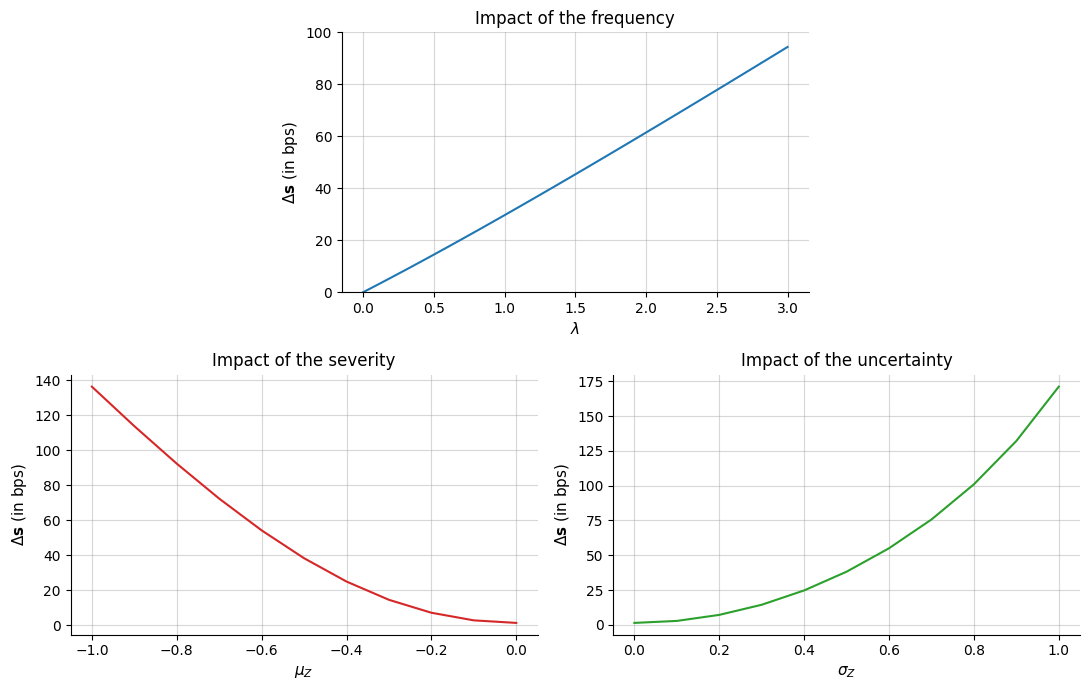

In [3]:
A0, sigma_A, D, T, r = 50, 0.25, 20, 10, 0.03
lambda0, mu_Z0, sigma_Z0 = 0.1, -0.1, 0.10


def spread(lam, mu_z, sigma_z):
    res = merton_jump_climate_model(A0, D, sigma_A, T, r, lam, mu_z, sigma_z)
    return -1 / T * np.log(res.b0 / D) - r


spread_no_climate = float(spread(0.0, mu_Z0, sigma_Z0))

x1 = np.arange(0, 3.01, 0.1)
y1 = 1e4 * (np.array([spread(x, mu_Z0, sigma_Z0) for x in x1]) - spread_no_climate)

x2 = np.arange(-1, 0.01, 0.1)
y2 = 1e4 * (np.array([spread(lambda0, x, sigma_Z0) for x in x2]) - spread_no_climate)

x3 = np.arange(0, 1.001, 0.1)
y3 = 1e4 * (np.array([spread(lambda0, mu_Z0, x) for x in x3]) - spread_no_climate)

fig = plt.figure(figsize=(11, 7))
gs = fig.add_gridspec(2, 4)
ax1 = fig.add_subplot(gs[0, 1:3])
ax2 = fig.add_subplot(gs[1, 0:2])
ax3 = fig.add_subplot(gs[1, 2:4])

panels9b = [
    (ax1, x1, y1, r"$\lambda$", "Impact of the frequency", color_blue, (0, 100), range(0, 101, 20)),
    (ax2, x2, y2, r"$\mu_Z$", "Impact of the severity", color_red, None, None),
    (ax3, x3, y3, r"$\sigma_Z$", "Impact of the uncertainty", color_green, None, None),
]
for ax, x, y, xlabel, title, c, ylim, yticks in panels9b:
    ax.plot(x, y, "-", color=c, linewidth=1.5)
    ax.grid(True, alpha=0.5)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(r"$\Delta \mathbf{s}$ (in bps)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if ylim is not None:
        ax.set_ylim(*ylim)
        ax.set_yticks(list(yticks))

plt.tight_layout()
plt.show()


## 3. Piecewise-exponential survival curves: baseline vs. climate scenarios (`chap13_credit10`)

A baseline piecewise-constant hazard-rate term structure (8 knots,
1-30y) vs. two "climate scenario" hazard bumps added at the longer
knots (scenario 1: small bumps starting at the 10y knot; scenario 2:
larger bumps across the whole curve), plus the implied 10y/20y PD
table.

,Baseline,Climate 1,Climate 2
10y,24.04,25.92,29.18
20y,49.08,55.07,61.13


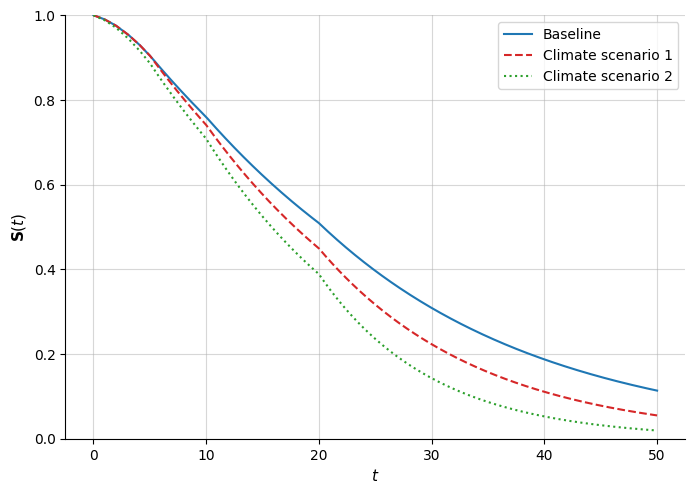

In [4]:
knots = np.array([1, 2, 3, 4, 5, 10, 20, 30])
lam_base = np.array([100, 150, 200, 250, 300, 350, 400, 500]) / 1e4
lam_climate1 = np.array([0, 0, 0, 0, 0, 50, 100, 200]) / 1e4
lam_climate2 = np.array([20, 30, 40, 50, 60, 100, 200, 500]) / 1e4

lam_all = np.column_stack([lam_base, lam_base + lam_climate1, lam_base + lam_climate2])
mat10 = np.column_stack([knots, lam_all])

t10 = np.arange(0, 50.01, 0.1)
S10 = survival_exponential(t10, mat10)

PD10 = 1 - survival_exponential(np.array([10, 20]), mat10)
display(pd.DataFrame(100 * PD10, index=["10y", "20y"], columns=["Baseline", "Climate 1", "Climate 2"]).round(2))

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(t10, S10[:, 0], "-", color=color_blue, linewidth=1.5, label="Baseline")
ax.plot(t10, S10[:, 1], "--", color=color_red, linewidth=1.5, label="Climate scenario 1")
ax.plot(t10, S10[:, 2], ":", color=color_green, linewidth=1.5, label="Climate scenario 2")

ax.set_xlabel("$t$", fontsize=11)
ax.set_ylabel(r"$\mathbf{S}(t)$", fontsize=11)
ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.01, 0.20))
plt.show()
